# Min-K% Prob — Master Notebook

This notebook orchestrates the full Min-K% Prob replication pipeline.
Each module calls a script in `scripts/` which in turn calls `src/`.
No logic is written inline here — the notebook is a runner, not a codebase.

**Isolation contract:**
- `src/` — pure Python logic (imported by scripts, tested by pytest)
- `scripts/` — orchestration, CLI entry points, Drive I/O
- This notebook — runs scripts, displays outputs, writes nothing to `src/`

---

## [0] Runtime and GPU Check

Verifies the Colab runtime has GPU access and confirms the Python environment before any module runs.

In [18]:
import torch, sys
print(f'Python  : {sys.version.split()[0]}')
print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
else:
    print('GPU     : None — switch Runtime > Change runtime type > GPU')

Python  : 3.12.13
PyTorch : 2.10.0+cu128
CUDA    : True
GPU     : Tesla T4


## [1] Drive Mount and Repository Setup

Mounts the shared Google Drive folder and clones the repository onto the Colab instance.
The `DRIVE` variable is set here and exported as an environment variable so all downstream scripts resolve their output paths without hardcoding.

> **First-time setup:** create the shared folder in Drive and share it with all team members before running this cell.

In [19]:
import os
from pathlib import Path
from google.colab import drive

drive.mount('/content/drive')

# Shared Drive folder (all members use the same path once shared)
DRIVE = '/content/drive/MyDrive/min-k-project-group2'
os.environ['DRIVE'] = DRIVE
Path(DRIVE).mkdir(parents=True, exist_ok=True)
print(f'Drive mounted at : {DRIVE}')

# Set environment variable for downstream scripts
%env DRIVE=/content/drive/MyDrive/min-k-project-group2

# Repo clone / pull
REPO_URL    = 'https://github.com/dazzlear/ai-final-project.git'
BRANCH      = 'codebase-cleanup'
PROJECT_DIR = '/content/ai-final-project'

if not Path(PROJECT_DIR).exists():
    !git clone {REPO_URL} {PROJECT_DIR}

%cd {PROJECT_DIR}
!git checkout {BRANCH}
!git pull origin {BRANCH}
print(f'Repo ready at : {PROJECT_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted at : /content/drive/MyDrive/min-k-project-group2
env: DRIVE=/content/drive/MyDrive/min-k-project-group2
/content/ai-final-project
Already on 'codebase-cleanup'
Your branch is up to date with 'origin/codebase-cleanup'.
remote: Enumerating objects: 11, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 7 (delta 4), reused 4 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (7/7), 115.43 KiB | 902.00 KiB/s, done.
From https://github.com/dazzlear/ai-final-project
 * branch            codebase-cleanup -> FETCH_HEAD
   cf2f044..30d3b91  codebase-cleanup -> origin/codebase-cleanup
Updating cf2f044..30d3b91
Fast-forward
 master_notebook.ipynb | 4681 ++++++++++++++++++++++++++++++++++++++-----------
 src/models.py         |    2 +-
 2 files changed, 3683 insertions(+), 1000 deletions(-

## [2] Configuration

**This is the only cell that should be edited between runs.**
All scripts read these variables via CLI arguments or the `DRIVE` environment variable.

| Variable | Purpose |
|---|---|
| `LENGTHS` | WikiMIA length buckets to process |
| `DEFAULT_MODEL` | Model used for smoke test and full runs |
| `SAMPLE_SIZE` | Rows per sample CSV (balanced: half per label) |
| `DRIVE` | Root of the shared Drive output folder |

In [20]:
# Edit this cell only

LENGTHS       = [32, 64, 128, 256]   # subset e.g. [64] for a quick test
DEFAULT_MODEL = 'EleutherAI/pythia-410m'
SAMPLE_SIZE   = 10

MODELS = {
    'pythia410m' : 'EleutherAI/pythia-410m',    # smoke-test model only
    'pythia2.8b' : 'EleutherAI/pythia-2.8b',
    'gptneo1.3b' : 'EleutherAI/gpt-neo-1.3B',
    'opt1.3b'    : 'facebook/opt-1.3b',
}
SMOKE_MODEL = 'pythia410m'

# Derived paths -- do not edit
DRIVE_01 = f'{DRIVE}/01_dataset'
DRIVE_02 = f'{DRIVE}/02_model_loading'
DRIVE_03 = f'{DRIVE}/03_mink_scores'
DRIVE_04 = f'{DRIVE}/04_baseline_scores'
DRIVE_05 = f'{DRIVE}/05_evaluation'

from pathlib import Path
for _d in [DRIVE_01, DRIVE_02, DRIVE_03, DRIVE_04, DRIVE_05]:
    Path(_d).mkdir(parents=True, exist_ok=True)

print('Config set:')
print(f'  LENGTHS       = {LENGTHS}')
print(f'  DEFAULT_MODEL = {DEFAULT_MODEL}')
print(f'  DRIVE_01      = {DRIVE_01}')

Config set:
  LENGTHS       = [32, 64, 128, 256]
  DEFAULT_MODEL = EleutherAI/pythia-410m
  DRIVE_01      = /content/drive/MyDrive/min-k-project-group2/01_dataset


## [3] Install Dependencies

Installs all required packages. This cell is idempotent — safe to re-run.

In [21]:
!pip install -q datasets transformers torch scikit-learn pandas numpy matplotlib tqdm

## [4] Module 01 — Dataset Loading and Preparation

Calls `scripts/run_01_dataset.py` to load, validate, and save all configured WikiMIA length splits from Hugging Face.

**What this section produces** (written to `{DRIVE}/01_dataset/`):

| File | Description |
|---|---|
| `wikimia_length{N}_processed.csv` | Full dataset for each length (used by Module 02) |
| `wikimia_length{N}_sample.csv` | 10-row balanced smoke-test sample |
| `summaries/dataset_summary_len{N}.txt` | Quality report per length |
| `summaries/dataset_summary_all.csv` | Combined summary across all lengths |

The script validates each split for missing values, empty texts, and label balance before saving.

In [ ]:
# Build the --lengths argument string from the config cell
_lengths_arg = ' '.join(str(l) for l in LENGTHS)

!python scripts/run_01_dataset.py \
    --lengths {_lengths_arg} \
    --output_dir {DRIVE_01} \
    --sample_size {SAMPLE_SIZE}

### 4.1 Output Preview

Displays the first few rows and label distribution for each processed length split.
Member (label=1) and non-member (label=0) counts should be equal for all lengths.

In [ ]:
from pathlib import Path
import pandas as pd

for length in LENGTHS:
    path = Path(DRIVE_01) / f'wikimia_length{length}_processed.csv'
    if path.exists():
        df = pd.read_csv(path)
        print(f'\n{"="*55}')
        print(f'  WikiMIA_length{length}  --  {len(df)} rows')
        print(f'{"="*55}')
        display(df.head(3))
        vc = df['label'].value_counts().rename({0: 'non-member (0)', 1: 'member (1)'})
        print(vc.to_string())
    else:
        print(f'[MISSING] {path}')

### 4.2 Module 01 Sanity Check

Verifies that every expected output file exists and that each dataset meets the minimum quality bar before proceeding to Module 02.

**Pass criteria (all must be green):**
- All processed CSVs present for every configured length
- All sample CSVs present
- No missing text or label values
- Labels are balanced (label_0 == label_1)
- No empty text rows

In [ ]:
from pathlib import Path
import pandas as pd

PASS = True

for length in LENGTHS:
    processed = Path(DRIVE_01) / f'wikimia_length{length}_processed.csv'
    sample    = Path(DRIVE_01) / f'wikimia_length{length}_sample.csv'
    summary   = Path(DRIVE_01) / 'summaries' / f'dataset_summary_len{length}.txt'

    checks = {
        f'processed CSV exists (len{length})': processed.exists(),
        f'sample CSV exists    (len{length})': sample.exists(),
        f'summary txt exists   (len{length})': summary.exists(),
    }

    if processed.exists():
        df = pd.read_csv(processed)
        checks[f'no missing text   (len{length})'] = df['text'].isna().sum() == 0
        checks[f'no missing labels (len{length})'] = df['label'].isna().sum() == 0
        checks[f'no empty texts    (len{length})'] = (df['text'].str.strip() == '').sum() == 0

        label_0 = int((df['label'] == 0).sum())
        label_1 = int((df['label'] == 1).sum())
        larger  = max(label_0, label_1)
        smaller = min(label_0, label_1)
        ratio   = smaller / larger

        if ratio < 0.90:
            # Imbalance is expected for longer lengths due to upstream filtering.
            # Logged as a warning — does not fail the pipeline.
            print(f'  ⚠️   label imbalance (len{length}): {label_0} vs {label_1} '
                  f'(ratio {ratio:.2f}) — known upstream dataset property')
        else:
            checks[f'labels balanced (len{length}) [{label_0} vs {label_1}]'] = True

    for name, ok in checks.items():
        icon = '✅' if ok else '❌'
        print(f'  {icon}  {name}')
        if not ok:
            PASS = False

master = Path(DRIVE_01) / 'summaries' / 'dataset_summary_all.csv'
icon = '✅' if master.exists() else '❌'
print(f'  {icon}  master summary CSV exists')
if not master.exists():
    PASS = False

print()
if PASS:
    print('✅  Module 01 PASSED — proceed to Module 02.')
else:
    print('❌  Module 01 FAILED — fix the issues above before running Module 02.')

## [5] Module 02 — Model Loading and Verification

Calls `scripts/run_02_model_loading.py` to load each model in the `MODELS`
config, run a diagnostics check, and save a verification report to Drive.
No log-probabilities are computed here — that is Module 03.

**What this section produces** (written to `{DRIVE}/02_model_loading/`):

| File | Description |
|---|---|
| `model_verification_report.csv` | One row per model: architecture, param count, VRAM, vocab size, roundtrip and forward-pass results |

The script loads each model, captures diagnostics, runs a tokenization
roundtrip and a single forward pass to confirm the model is functional,
then unloads it before moving to the next. All four models are verified
in sequence.

> **Before running:** confirm Module 01 passed (all ✅ in §4.2).

In [ ]:
# ── Module 02 run ─────────────────────────────────────────────────────────────
# Verifies all models in MODELS can load and produce logits.
# Outputs: model_verification_report.csv in DRIVE_02.

_models_arg = ' '.join(MODELS.values())

!python scripts/run_02_model_loading.py \
    --models {_models_arg} \
    --output_dir {DRIVE_02}

### 5.1 Output Preview

Displays the verification report table. Every model should show
`roundtrip_ok = True` and `forward_pass_ok = True` before proceeding.
VRAM readings confirm the model fit in GPU memory without OOM.

In [ ]:
from pathlib import Path
import pandas as pd

report_path = Path(DRIVE_02) / 'model_verification_report.csv'

if report_path.exists():
    df_report = pd.read_csv(report_path)
    display(df_report[[
        'model_key', 'architecture', 'parameters_M',
        'vram_mb', 'vocab_size', 'roundtrip_ok', 'forward_pass_ok'
    ]])

    failed = df_report[
        ~df_report['roundtrip_ok'] | ~df_report['forward_pass_ok']
    ]
    if len(failed) == 0:
        print('\nAll models passed verification ✅')
    else:
        print('\n⚠️  Failed models:')
        print(failed[['model_key', 'roundtrip_ok', 'forward_pass_ok']].to_string(index=False))
else:
    print(f'[MISSING] {report_path}')
    print('Re-run the cell above.')

### 5.2 Module 02 Sanity Check

Verifies the verification report exists and that every configured model
passed both checks before proceeding to Module 03.

**Pass criteria (all must be green):**
- `model_verification_report.csv` present
- One row per model in `MODELS`
- All rows: `roundtrip_ok = True`
- All rows: `forward_pass_ok = True`

In [ ]:
from pathlib import Path
import pandas as pd

PASS = True
report_path = Path(DRIVE_02) / 'model_verification_report.csv'

# ── Report file exists ────────────────────────────────────────────────────────
report_ok = report_path.exists()
print(f'  {"✅" if report_ok else "❌"}  model_verification_report.csv exists')
if not report_ok:
    PASS = False
else:
    df_r = pd.read_csv(report_path)

    # ── Row count matches MODELS ──────────────────────────────────────────────
    expected_n = len(MODELS)
    found_n    = len(df_r)
    count_ok   = found_n == expected_n
    print(f'  {"✅" if count_ok else "❌"}  row count: {found_n} / {expected_n} expected')
    if not count_ok:
        PASS = False

    # ── Per-model checks ──────────────────────────────────────────────────────
    print()
    for _, row in df_r.iterrows():
        rt_ok = bool(row['roundtrip_ok'])
        fp_ok = bool(row['forward_pass_ok'])
        icon  = '✅' if (rt_ok and fp_ok) else '❌'
        print(f'  {icon}  {row["model_key"]:15s}  '
              f'roundtrip={rt_ok}  forward_pass={fp_ok}  '
              f'{row["parameters_M"]:.0f}M params  {row["vram_mb"]:.0f} MB VRAM')
        if not (rt_ok and fp_ok):
            PASS = False

print()
if PASS:
    print('✅  Module 02 PASSED — proceed to Module 03.')
else:
    print('❌  Module 02 FAILED — fix the issues above before running Module 03.')

## [6] Module 03 — Min-K% Prob Scoring

Calls `scripts/run_03_mink.py` to compute Min-K% Prob scores for every
configured **model × length × setting** combination.

**What this module does:**
The Min-K% Prob method (Shi et al., ICLR 2024, Eq. 1) detects whether a text
was seen during LLM pretraining by examining the *lowest-probability tokens*
in that text.  The intuition: a model assigns higher probabilities to tokens
it has memorised; unseen text is more likely to contain surprising (low-prob)
outlier tokens.

**Four pipeline stages:**

| Stage | Function | Description |
|-------|----------|-------------|
| 1 | `tokenize_text()` | Split text into subword tokens |
| 2 | `compute_token_logprobs()` | Forward pass → per-token log p |
| 3 | `select_min_k_tokens()` | Pick bottom k% by log probability |
| 4 | `min_k_prob()` | Average log-prob of selected set |

**Output CSV schema** (text_id, text, label, min_k_score, n_tokens, n_selected) — locked for Modules 04 and 05.

---

### 6.0 Stage-by-Stage Visualization

Load pythia-410m (smallest model) and walk through all four pipeline stages on sample texts for understanding.
This cell does NOT affect the full-run outputs.

In [ ]:
import sys, os
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Ensure src/ is on path
_src = os.path.join(os.environ.get('PROJECT_DIR', '/content/ai-final-project'), 'src')
if _src not in sys.path:
    sys.path.insert(0, _src)

from models  import load_model
from methods import tokenize_text, compute_token_logprobs, select_min_k_tokens, min_k_prob

VIZ_MODEL  = 'EleutherAI/pythia-410m'
VIZ_K      = 20
VIZ_LENGTH = 64
VIZ_N      = 3

# Load sample from Module 01 output
_sample_csv = f'{DRIVE_01}/wikimia_length{VIZ_LENGTH}_sample.csv'
df_sample   = pd.read_csv(_sample_csv)

_members     = df_sample[df_sample['label'] == 1].head(2)
_non_members = df_sample[df_sample['label'] == 0].head(1)
viz_rows     = pd.concat([_members, _non_members]).reset_index(drop=True)

print(f'Visualisation sample ({VIZ_N} rows):')
print(viz_rows[['text_id', 'label', 'text']].to_string(max_colwidth=80))

Visualisation sample (3 rows):
   text_id  label                                                                             text
0      476      1  The Rotherham child sexual exploitation scandal consists of the organised ch...
1       14      1  The Pocklington Iron Age burial ground is a prehistoric cemetery discovered ...
2      155      0  The 2023 Las Anod conflict is an ongoing armed conflict between the Somalila...


### 6.0.1 Load Model

In [ ]:
print(f'Loading {VIZ_MODEL} for stage-by-stage demo ...')
_viz_model, _viz_tokenizer = load_model(VIZ_MODEL)
print('Model loaded.')

Loading EleutherAI/pythia-410m for stage-by-stage demo ...
[load_model] Loading 'EleutherAI/pythia-410m' ...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/911M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/396 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

[load_model] Done.
Model loaded.


### 6.0.2 Stage 1 — Tokenization

In [ ]:
print('=' * 65)
print('STAGE 1 — Tokenization')
print('=' * 65)
print('Each text is split into subword tokens using the model\'s tokenizer.')
print('These token IDs are the inputs to the forward pass in Stage 2.\n')

_stage1_results = []
for _, row in viz_rows.iterrows():
    tok = tokenize_text(row['text'], _viz_tokenizer)
    _stage1_results.append(tok)

    label_str = 'MEMBER (1)' if row['label'] == 1 else 'NON-MEMBER (0)'
    print(f'text_id={row["text_id"]}  label={label_str}')
    print(f'  n_tokens     : {tok["n_tokens"]}')
    print(f'  was_truncated: {tok["was_truncated"]}')
    preview = list(zip(tok["input_ids"][:12], tok["tokens"][:12]))
    print(f'  token preview (first 12):')
    for tid, tstr in preview:
        print(f'    {tid:>6}  {repr(tstr)}')
    if tok["n_tokens"] > 12:
        print(f'    ... {tok["n_tokens"] - 12} more tokens ...')
    print()

STAGE 1 — Tokenization
Each text is split into subword tokens using the model's tokenizer.
These token IDs are the inputs to the forward pass in Stage 2.

text_id=476  label=MEMBER (1)
  n_tokens     : 78
  was_truncated: False
  token preview (first 12):
       510  'The'
       416  ' R'
       977  'other'
      3964  'ham'
      1429  ' child'
      5615  ' sexual'
     30211  ' exploitation'
     20565  ' scandal'
      8414  ' consists'
       273  ' of'
       253  ' the'
     29070  ' organised'
    ... 66 more tokens ...

text_id=14  label=MEMBER (1)
  n_tokens     : 79
  was_truncated: False
  token preview (first 12):
       510  'The'
       367  ' P'
       825  'ock'
     25185  'lington'
     17826  ' Iron'
     11362  ' Age'
     33672  ' burial'
      3216  ' ground'
       310  ' is'
       247  ' a'
       638  ' pre'
     43957  'historic'
    ... 67 more tokens ...

text_id=155  label=NON-MEMBER (0)
  n_tokens     : 97
  was_truncated: False
  token preview (first 

### 6.0.3 Stage 2 — Token Log Probabilities

STAGE 2 — Token Log Probabilities
One forward pass returns log p(xi | x<i) for each predicted token.
More negative = the token surprised the model.

text_id=476  label=MEMBER (1)
  n_predicted_tokens : 77
  mean log-prob      : -2.7761
  min  log-prob      : -10.1562
  max  log-prob      : -0.0011
  first 8 values     : [-6.801, -7.266, -0.721, -7.055, -4.848, -1.205, -3.518, -10.156]

text_id=14  label=MEMBER (1)
  n_predicted_tokens : 78
  mean log-prob      : -2.8691
  min  log-prob      : -9.2969
  max  log-prob      : -0.0017
  first 8 values     : [-6.527, -8.547, -1.868, -8.422, -5.785, -3.721, -2.213, -2.002]

text_id=155  label=NON-MEMBER (0)
  n_predicted_tokens : 96
  mean log-prob      : -3.6990
  min  log-prob      : -16.1094
  max  log-prob      : -0.0007
  first 8 values     : [-8.633, -7.617, -11.078, -12.641, -5.398, -16.109, -2.131, -3.348]



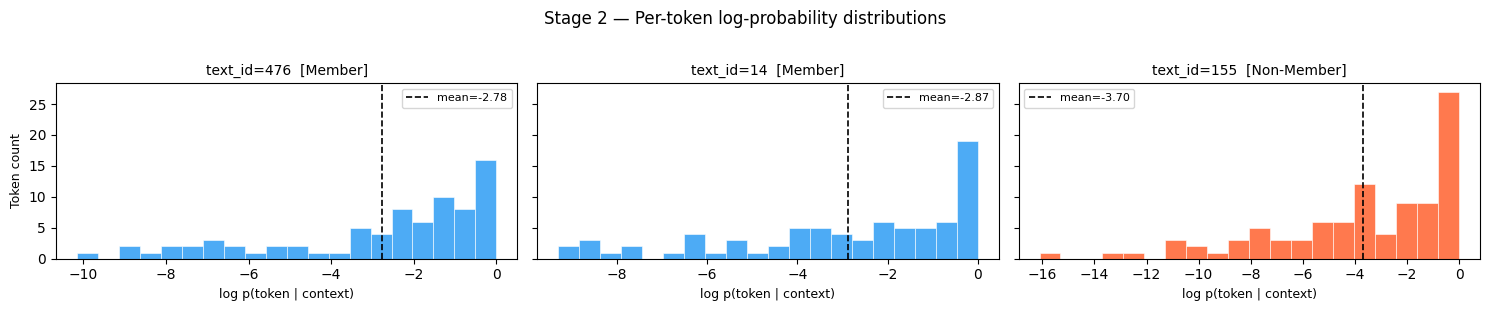

Saved: viz_stage2_logprob_distributions.png


In [ ]:
print('=' * 65)
print('STAGE 2 — Token Log Probabilities')
print('=' * 65)
print('One forward pass returns log p(xi | x<i) for each predicted token.')
print('More negative = the token surprised the model.\n')

_stage2_results = []
for idx, (_, row) in enumerate(viz_rows.iterrows()):
    lp = compute_token_logprobs(row['text'], _viz_model, _viz_tokenizer)
    _stage2_results.append(lp)

    label_str = 'MEMBER (1)' if row['label'] == 1 else 'NON-MEMBER (0)'
    print(f'text_id={row["text_id"]}  label={label_str}')
    print(f'  n_predicted_tokens : {len(lp)}')
    print(f'  mean log-prob      : {np.mean(lp):.4f}')
    print(f'  min  log-prob      : {np.min(lp):.4f}')
    print(f'  max  log-prob      : {np.max(lp):.4f}')
    print(f'  first 8 values     : {[round(v,3) for v in lp[:8]]}')
    print()

# Visualise log-prob distributions
fig, axes = plt.subplots(1, VIZ_N, figsize=(5 * VIZ_N, 3), sharey=True)
colors = {1: '#2196F3', 0: '#FF5722'}

for ax, (_, row), lp in zip(axes, viz_rows.iterrows(), _stage2_results):
    c = colors[row['label']]
    ax.hist(lp, bins=20, color=c, alpha=0.8, edgecolor='white', linewidth=0.5)
    ax.axvline(np.mean(lp), color='black', linestyle='--', linewidth=1.2,
               label=f'mean={np.mean(lp):.2f}')
    label_str = 'Member' if row['label'] == 1 else 'Non-Member'
    ax.set_title(f'text_id={row["text_id"]}  [{label_str}]', fontsize=10)
    ax.set_xlabel('log p(token | context)', fontsize=9)
    ax.legend(fontsize=8)

axes[0].set_ylabel('Token count', fontsize=9)
fig.suptitle('Stage 2 — Per-token log-probability distributions', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(f'{DRIVE_03}/viz_stage2_logprob_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: viz_stage2_logprob_distributions.png')

### 6.0.4 Stage 3 — Select Bottom K% Tokens

STAGE 3 — Select Bottom 20% Tokens (Min-K% set)
Tokens are ranked by log-prob ascending (most surprising first).
The bottom 20% by count are selected as the Min-K% set.

text_id=476  label=MEMBER (1)
  total tokens    : 77
  k=20%  →  n_selected : 16
  selected token positions : [7, 72, 10, 57, 51, 27, 1, 60, 3, 36, 0, 67, 52, 62, 40, 70]
  selected tokens  : ["' consists'", "' warned'", "' organised'", "' Res'", "' throughout'", "' Northern'", "'other'", "' Ang'", "' child'", "' 2010'"]...
  selected log-probs: [-10.156, -8.711, -8.68, -8.633, -7.805, -7.703, -7.266, -7.191, -7.055, -6.902]...
  mean of selected : -7.2734

text_id=14  label=MEMBER (1)
  total tokens    : 78
  k=20%  →  n_selected : 16
  selected token positions : [55, 71, 56, 1, 3, 58, 39, 66, 0, 68, 63, 72, 32, 4, 12, 9]
  selected tokens  : ["' square'", "' Ar'", "' b'", "'ock'", "' Iron'", "' thought'", "' ongoing'", "' that'", "' P'", "' attributed'"]...
  selected log-probs: [-9.297, -9.125, -8.578, -8.547, -8.42

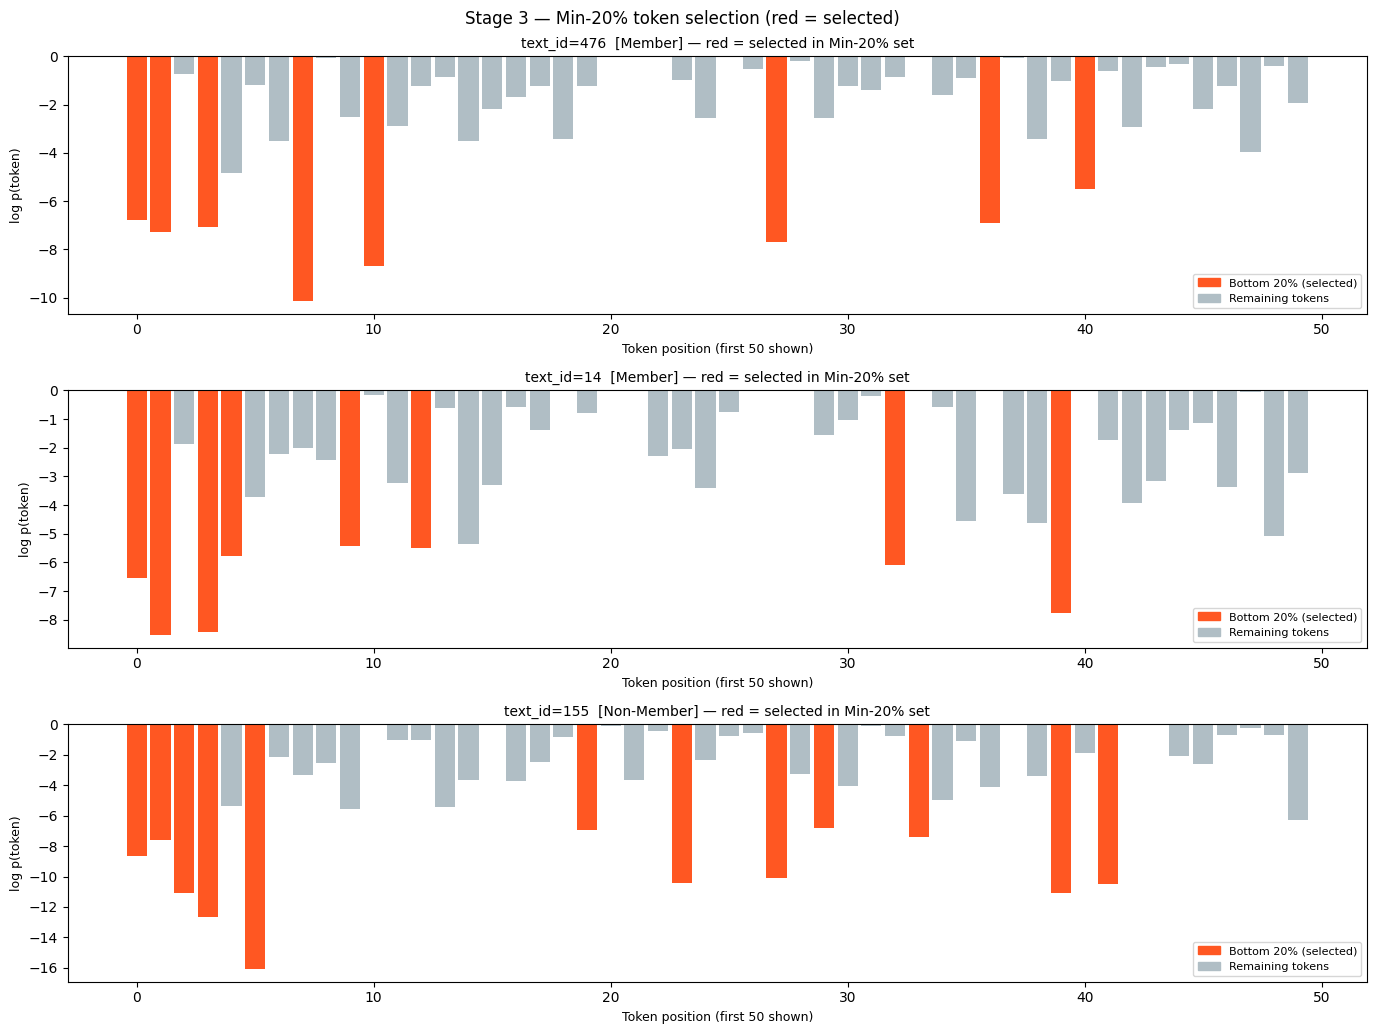

Saved: viz_stage3_token_selection.png


In [ ]:
print('=' * 65)
print(f'STAGE 3 — Select Bottom {VIZ_K}% Tokens (Min-K% set)')
print('=' * 65)
print('Tokens are ranked by log-prob ascending (most surprising first).')
print(f'The bottom {VIZ_K}% by count are selected as the Min-K% set.\n')

_stage3_results = []
tok_preview_data = []

for idx, (_, row) in enumerate(viz_rows.iterrows()):
    lp   = _stage2_results[idx]
    tok  = _stage1_results[idx]

    sel_idx, sel_lp, rank_order = select_min_k_tokens(lp, k=VIZ_K)
    _stage3_results.append((sel_idx, sel_lp))

    label_str = 'MEMBER (1)' if row['label'] == 1 else 'NON-MEMBER (0)'
    print(f'text_id={row["text_id"]}  label={label_str}')
    print(f'  total tokens    : {len(lp)}')
    print(f'  k={VIZ_K}%  →  n_selected : {len(sel_idx)}')
    print(f'  selected token positions : {sel_idx}')

    sel_tokens = [tok['tokens'][i + 1] if i + 1 < len(tok['tokens']) else '<OOB>'
                  for i in sel_idx]
    print(f'  selected tokens  : {[repr(t) for t in sel_tokens[:10]]}{"..." if len(sel_tokens) > 10 else ""}')
    print(f'  selected log-probs: {[round(v,3) for v in sel_lp[:10]]}{"..." if len(sel_lp) > 10 else ""}')
    print(f'  mean of selected : {np.mean(sel_lp):.4f}')
    print()

    tok_preview_data.append({
        'text_id'   : row['text_id'],
        'label'     : row['label'],
        'lp'        : lp,
        'sel_idx'   : set(sel_idx),
    })

# Per-token bar chart with selected tokens highlighted
fig, axes = plt.subplots(VIZ_N, 1, figsize=(14, 3.5 * VIZ_N))
if VIZ_N == 1:
    axes = [axes]

for ax, data in zip(axes, tok_preview_data):
    lp      = data['lp']
    sel_set = data['sel_idx']
    n_show  = min(50, len(lp))

    bar_colors = ['#FF5722' if i in sel_set else '#B0BEC5' for i in range(n_show)]
    ax.bar(range(n_show), lp[:n_show], color=bar_colors, width=0.85, edgecolor='none')

    label_str = 'Member' if data['label'] == 1 else 'Non-Member'
    ax.set_title(f'text_id={data["text_id"]}  [{label_str}] — red = selected in Min-{VIZ_K}% set',
                 fontsize=10)
    ax.set_xlabel('Token position (first 50 shown)', fontsize=9)
    ax.set_ylabel('log p(token)', fontsize=9)
    ax.axhline(0, color='gray', linewidth=0.5)

    red_patch  = mpatches.Patch(color='#FF5722', label=f'Bottom {VIZ_K}% (selected)')
    grey_patch = mpatches.Patch(color='#B0BEC5', label='Remaining tokens')
    ax.legend(handles=[red_patch, grey_patch], fontsize=8, loc='lower right')

fig.suptitle(f'Stage 3 — Min-{VIZ_K}% token selection (red = selected)', fontsize=12)
plt.tight_layout()
plt.savefig(f'{DRIVE_03}/viz_stage3_token_selection.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: viz_stage3_token_selection.png')

### 6.0.5 Stage 4 — Min-K% Prob Score

In [ ]:
print('=' * 65)
print('STAGE 4 — Min-K% Prob Score (Equation 1)')
print('=' * 65)
print('The final score is the mean log-prob of selected (bottom-k%) tokens.')
print('Higher (less negative) = model assigns higher probs → more likely MEMBER.\n')

summary_rows = []
for idx, (_, row) in enumerate(viz_rows.iterrows()):
    lp    = _stage2_results[idx]
    score = min_k_prob(lp, k=VIZ_K)
    _, sel_lp = _stage3_results[idx]

    label_str = 'MEMBER (1)' if row['label'] == 1 else 'NON-MEMBER (0)'
    print(f'text_id={row["text_id"]}  label={label_str}')
    print(f'  all-token mean log-prob : {np.mean(lp):.4f}')
    print(f'  Min-K% Prob score       : {score:.4f}   <── detection score')
    print()
    summary_rows.append({
        'text_id'      : row['text_id'],
        'label'        : row['label'],
        'all_mean_lp'  : round(np.mean(lp), 4),
        'min_k_score'  : round(score, 4),
    })

print('Summary table:')
print(pd.DataFrame(summary_rows).to_string(index=False))
print()
print('Expected: member min_k_score > non-member min_k_score')
m1 = np.mean([r['min_k_score'] for r in summary_rows if r['label'] == 1])
m0 = np.mean([r['min_k_score'] for r in summary_rows if r['label'] == 0])
direction = '✅ correct direction' if m1 > m0 else '⚠️  unexpected — may be due to small sample'
print(f'  member mean    : {m1:.4f}')
print(f'  non-member mean: {m0:.4f}   {direction}')

del _viz_model, _viz_tokenizer
torch.cuda.empty_cache()
print('\nGPU cache cleared. Ready for full dataset run.')

STAGE 4 — Min-K% Prob Score (Equation 1)
The final score is the mean log-prob of selected (bottom-k%) tokens.
Higher (less negative) = model assigns higher probs → more likely MEMBER.

text_id=476  label=MEMBER (1)
  all-token mean log-prob : -2.7761
  Min-K% Prob score       : -7.2734   <── detection score

text_id=14  label=MEMBER (1)
  all-token mean log-prob : -2.8691
  Min-K% Prob score       : -7.2231   <── detection score

text_id=155  label=NON-MEMBER (0)
  all-token mean log-prob : -3.6990
  Min-K% Prob score       : -9.4342   <── detection score

Summary table:
 text_id  label  all_mean_lp  min_k_score
     476      1      -2.7761      -7.2734
      14      1      -2.8691      -7.2231
     155      0      -3.6990      -9.4342

Expected: member min_k_score > non-member min_k_score
  member mean    : -7.2482
  non-member mean: -9.4342   ✅ correct direction

GPU cache cleared. Ready for full dataset run.


### 6.1 Smoke Test

Validates the full script pipeline on 10 rows with the smallest model before committing to the multi-hour run.
Output: `mink_scores_pythia410m_len64_original.csv` (10 rows)

In [22]:
_lengths_arg    = ' '.join(str(l) for l in LENGTHS)
_models_arg     = ' '.join(MODELS.values())
_model_keys_arg = ' '.join(MODELS.keys())
_settings_arg   = ' '.join(['original'])

_smoke_models_arg     = 'EleutherAI/pythia-410m'
_smoke_model_keys_arg = 'pythia410m'

!python scripts/run_03_mink_scores.py \
    --input_dir  {DRIVE_01} \
    --output_dir {DRIVE_03} \
    --models     {_smoke_models_arg} \
    --model_keys {_smoke_model_keys_arg} \
    --lengths    64 \
    --settings   original \
    --k          20 \
    --smoke

print('\nSmoke test output preview:')
import pandas as pd
_smoke_csv = f'{DRIVE_03}/mink_scores_pythia410m_len64_original.csv'
df_smoke   = pd.read_csv(_smoke_csv)
display(df_smoke[['text_id', 'label', 'min_k_score', 'n_tokens', 'n_selected']])


Module 03 — Min-K% Prob Scoring
k=20  device=cuda  smoke=True
models   : ['pythia410m']
lengths  : [64]
settings : ['original']

Model: pythia410m (EleutherAI/pythia-410m)
  Loading model ...
[load_model] Loading 'EleutherAI/pythia-410m' ...
Loading weights: 100% 292/292 [00:00<00:00, 900.73it/s, Materializing param=gpt_neox.layers.23.post_attention_layernorm.weight]
[load_model] Done.
  Loaded in 2.2s

  combo: len=64  setting=original
  [SMOKE] using first 10 rows
  scoring 10 rows ...
  [  10/10]  elapsed 0s  ETA 0s
  saved: /content/drive/MyDrive/min-k-project-group2/03_mink_scores/mink_scores_pythia410m_len64_original.csv
  member_mean=-6.8415  non_member_mean=-7.9834  (member > non-member)

  GPU cache cleared.

DONE.  completed=1  skipped=0  failed=0

Smoke test output preview:


,text_id,label,min_k_score,n_tokens,n_selected
0,0,0,-7.840074,85,17
1,1,1,-6.774127,82,17
2,2,0,-8.126776,106,22
3,3,1,-6.798340,78,16
4,4,1,-5.694770,89,18
5,5,1,-6.195557,76,16
6,6,1,-8.535156,87,18
7,7,1,-8.081801,85,17
8,8,1,-6.205200,78,16
9,9,1,-6.447266,90,18


### 6.2 Full Dataset Run

Computes scores for all models × lengths × settings combinations.
Estimated time on T4 GPU: 2–3 hours per large model.
Each CSV is written to Drive immediately; re-run with `--skip_existing` if interrupted.

In [24]:
!python scripts/run_03_mink_scores.py \
    --input_dir     {DRIVE_01} \
    --output_dir    {DRIVE_03} \
    --models        {_models_arg} \
    --model_keys    {_model_keys_arg} \
    --lengths       {_lengths_arg} \
    --settings      {_settings_arg} \
    --k             20 \
    --skip_existing \
    --cache_logprobs

usage: run_03_mink_scores.py [-h] --input_dir INPUT_DIR --output_dir
                             OUTPUT_DIR --models MODELS [MODELS ...]
                             --model_keys MODEL_KEYS [MODEL_KEYS ...]
                             [--lengths LENGTHS [LENGTHS ...]]
                             [--settings {original,paraphrase} [{original,paraphrase} ...]]
                             [--k K] [--skip_existing] [--cache_logprobs]
                             [--smoke]
run_03_mink_scores.py: error: argument --lengths: invalid int value: '32 64 128 256'


### 6.3 Output Preview

Displays summary statistics (member mean vs non-member mean) for each model × length × setting.

In [ ]:
from pathlib import Path
import pandas as pd

_length = LENGTHS[0]

for model_key in MODELS:
    for setting in ['original', 'paraphrase']:
        csv_path = Path(DRIVE_03) / f'mink_scores_{model_key}_len{_length}_{setting}.csv'
        if csv_path.exists():
            df = pd.read_csv(csv_path)
            m1 = df[df['label'] == 1]['min_k_score'].mean()
            m0 = df[df['label'] == 0]['min_k_score'].mean()
            print(f'\n{model_key}  |  len={_length}  |  {setting}  ({len(df)} rows)')
            print(f'  member mean    : {m1:.4f}')
            print(f'  non-member mean: {m0:.4f}')
            print()
            display(df[['text_id', 'label', 'min_k_score', 'n_tokens', 'n_selected']].head(6))
        else:
            print(f'[MISSING] {csv_path.name}')

### 6.4 Module 03 Sanity Check

Verifies all expected outputs exist and meet quality requirements.

**Pass criteria:**
- Score CSV exists for every model × length × setting
- Row count matches Module 01 processed CSV
- No NaN min_k_score values
- Score direction: member mean > non-member mean (at least on len=64 original)
- n_selected calculation is correct

In [ ]:
from pathlib import Path
import math
import pandas as pd

PASS = True
K_CHECK = 20

for model_key in MODELS:
    for length in LENGTHS:
        for setting in ['original', 'paraphrase']:
            csv_path = Path(DRIVE_03) / f'mink_scores_{model_key}_len{length}_{setting}.csv'
            ref_csv  = Path(DRIVE_01) / f'wikimia_length{length}_processed.csv'

            exists = csv_path.exists()
            icon   = '✅' if exists else '❌'
            label  = f'{model_key} | len={length} | {setting}'
            print(f'  {icon}  CSV exists         {label}')
            if not exists:
                PASS = False
                continue

            df = pd.read_csv(csv_path)

            if ref_csv.exists():
                expected = len(pd.read_csv(ref_csv))
                count_ok = len(df) == expected
                icon     = '✅' if count_ok else '⚠️ '
                print(f'  {icon}  row count          {label}: {len(df)} / {expected}')
                if not count_ok:
                    PASS = False

            nan_ok = df['min_k_score'].isna().sum() == 0
            icon   = '✅' if nan_ok else '❌'
            print(f'  {icon}  no NaN scores      {label}')
            if not nan_ok:
                PASS = False

            m1  = df[df['label'] == 1]['min_k_score'].mean()
            m0  = df[df['label'] == 0]['min_k_score'].mean()
            dir_ok = m1 > m0
            icon   = '✅' if dir_ok else '⚠️ '
            print(f'  {icon}  direction (m1>m0)  {label}: {m1:.4f} > {m0:.4f}')
            if not dir_ok:
                PASS = False

            expected_sel = df['n_tokens'].apply(lambda n: max(1, math.ceil(n * K_CHECK / 100)))
            sel_ok = (df['n_selected'] == expected_sel).all()
            icon   = '✅' if sel_ok else '❌'
            print(f'  {icon}  n_selected correct {label}')
            if not sel_ok:
                PASS = False

            print()

print()
if PASS:
    print('✅  Module 03 PASSED — proceed to Module 04.')
else:
    print('❌  Module 03 FAILED — fix issues above before running Module 04.')